In [ ]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [54]:
df = pd.read_csv("ANEMIA_DA.csv", sep = ";")
df['GRADO_SEVERIDAD'] = df['GRADO_SEVERIDAD'].str.upper()
df['ETNIA_AGRUPADA'] = df['ETNIA'].mask(df['ETNIA'].str.upper() != 'MESTIZO', 'INDIGENA')


# 1. Diccionario de Datos: Dataset de Anemia (HISMINSA)

Este conjunto de datos contiene los registros de detección de anemia en niños menores de 5 años, integrando variables clínicas, demográficas y geográficas.

| Variable | Descripción | Tipo | Tamaño | Notas Adicionales |
| :--- | :--- | :--- | :--- | :--- |
| **PK_REGISTRO** | Código identificador único del registro | Numérico | 10 | Clave primaria. |
| **FECHA_REGISTRO** | Fecha de registro en el sistema | Texto | 8 | Formato: `aaaammdd`. |
| **GENERO** | Sexo del paciente | Texto | 1 | M = Masculino, F = Femenino. |
| **EDAD_REGISTRO** | Valor numérico de la edad | Numérico | 4 | Edad al ser atendido. |
| **TIPO_EDAD** | Unidad de medida de la edad | Texto | 1 | A=Años, M=Meses, D=Días. |
| **ETNIA** | Grupo étnico del paciente | Texto | 20 | Autoidentificación. |
| **F_ATENCION** | Fecha de la prestación de salud | Texto | 8 | Formato: `aaaammdd`. |
| **GRADO_SEVERIDAD** | Nivel de anemia detectado (**Target**) | Texto | 5 | LEV, MOD, SEV. |
| **DIAGNOSTICO** | Descripción del diagnóstico médico | Texto | 900 | Detalle clínico. |
| **TIPO_DIAGNOSTICO** | Categoría de la evaluación | Texto | 1 | D=Definitivo, P=Presuntivo, R=Repetitivo. |
| **DESCRIPCION_FINANCIADOR** | Entidad que cubre el gasto (Seguro) | Texto | 200 | Ej: SIS, EsSalud. |
| **CANTIDAD** | Total de diagnósticos realizados | Numérico | 4 | Conteo por registro. |
| **PROVINCIA** | Provincia de residencia del paciente | Texto | 510 | Geografía política. |
| **DEPARTAMENTO** | Departamento de residencia del paciente | Texto | 510 | Geografía política. |
| **DISTRITO** | Distrito de residencia del paciente | Texto | 510 | Geografía política. |
| **RED** | Red de salud encargada | Texto | 510 | Administración MINSA. |
| **MICRORED** | Microred de salud específica | Texto | 510 | Administración MINSA. |
| **NOMBRE_ESTABLECIMIENTO** | Nombre de la IPRESS de atención | Texto | 200 | Local de salud. |
| **CODIGO_UNICO** | Código de identificación de red | Numérico | 10 | ID administrativo. |
| **LONGITUD** | Coordenada geográfica (Longitud) | Decimal | 50 | Punto X del establecimiento. |
| **LATITUD** | Coordenada geográfica (Latitud) | Decimal | 50 | Punto Y del establecimiento. |
| **FECHA_CORTE** | Fecha de exportación de los datos | Numérico | 8 | Última actualización. |

---

In [56]:
df.head()

,PK_REGISTRO,FECHA_REGISTRO,GENERO,EDAD_REGISTRO,TIPO_EDAD,ETNIA,F_ATENCION,GRADO_SEVERIDAD,DIAGNOSTICO,TIPO_DIAGNOSTICO,...,DEPARTAMENTO,DISTRITO,RED,MICRORED,NOMBRE_ESTABLECIMIENTO,CODIGO_UNICO,LONGITUD,LATITUD,FECHA_CORTE,ETNIA_AGRUPADA
0,1,20180810,M,5,A,Mestizo,20180810,MOD,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,HUICUNGO,MARISCAL CACERES,HUICUNGO,PIZARRO,6571,-76.985172,-7.250180,20250424,Mestizo
1,2,20170406,M,3,A,Mestizo,20170406,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,TARAPOTO,SAN MARTIN,TARAPOTO,HUAYCO TARAPOTO,6371,-76.367503,-6.502062,20250424,Mestizo
2,3,20180719,F,5,A,Mestizo,20180719,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,SAN JOSE DE SISA,EL DORADO,SAN JOSE DE SISA,HOSPITAL RURAL SAN JOSE DE SISA,6485,-76.688596,-6.614755,20250424,Mestizo
3,4,20170912,M,4,A,Mestizo,20170912,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,RIOJA,RIOJA,NUEVO RIOJA,LA PERLA DE CASCAYUNGA,6708,-77.236470,-6.092303,20250424,Mestizo
4,5,20180718,F,5,A,Mestizo,20180718,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,...,SAN MARTIN,SAN JOSE DE SISA,EL DORADO,SAN JOSE DE SISA,HOSPITAL RURAL SAN JOSE DE SISA,6485,-76.688596,-6.614755,20250424,Mestizo


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59225 entries, 0 to 59224
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PK_REGISTRO              59225 non-null  int64  
 1   FECHA_REGISTRO           59225 non-null  int64  
 2   GENERO                   59225 non-null  object 
 3   EDAD_REGISTRO            59225 non-null  int64  
 4   TIPO_EDAD                59225 non-null  object 
 5   ETNIA                    59225 non-null  object 
 6   F_ATENCION               59225 non-null  int64  
 7   GRADO_SEVERIDAD          59225 non-null  object 
 8   DIAGNOSTICO              59225 non-null  object 
 9   TIPO_DIAGNOSTICO         59225 non-null  object 
 10  DESCRIPCION_FINANCIADOR  59225 non-null  object 
 11  CANTIDAD                 59225 non-null  int64  
 12  PROVINCIA                59225 non-null  object 
 13  DEPARTAMENTO             59225 non-null  object 
 14  DISTRITO              

In [49]:
df.describe()

,PK_REGISTRO,FECHA_REGISTRO,EDAD_REGISTRO,F_ATENCION,CANTIDAD,CODIGO_UNICO,LONGITUD,LATITUD,FECHA_CORTE
count,59225.000000,5.922500e+04,59225.000000,5.922500e+04,59225.000000,59225.000000,59225.000000,59225.000000,59225.0
mean,29613.000000,2.020370e+07,3.481857,2.020370e+07,1.007092,6504.450536,-76.616940,-6.604169,20250424.0
std,17096.929183,2.256667e+04,2.664805,2.256667e+04,0.084913,978.482362,0.386289,0.623823,0.0
min,1.000000,2.016010e+07,-2.000000,2.016010e+07,1.000000,6270.000000,-77.634017,-8.753550,20250424.0
25%,14807.000000,2.018120e+07,1.000000,2.018120e+07,1.000000,6352.000000,-76.850305,-6.792527,20250424.0
50%,29613.000000,2.020083e+07,3.000000,2.020083e+07,1.000000,6406.000000,-76.577641,-6.485973,20250424.0
75%,44419.000000,2.022091e+07,6.000000,2.022091e+07,1.000000,6494.000000,-76.355165,-6.154090,20250424.0
max,59225.000000,2.025043e+07,80.000000,2.025043e+07,3.000000,31276.000000,-75.593100,-5.639154,20250424.0


<Axes: xlabel='GRADO_SEVERIDAD'>

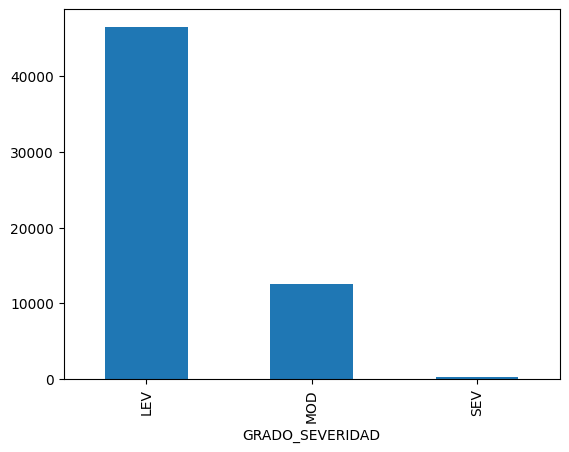

In [57]:
(df['GRADO_SEVERIDAD'].value_counts()).plot(kind='bar')